<a href="https://colab.research.google.com/github/HunterL28/Alzheimer-sBioinformaticsProject/blob/main/Alzheimer's_scRNA_seq_example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%pip install scanpy python-igraph leidenalg

In [2]:

# import packages
import numpy as np
import pandas as pd
import scanpy as sc

In [3]:
sc.settings.verbosity = 3   # verbosity: errors (0), warnings (1), info (2), hints (3)

In [6]:
# customize resolution and color of your figures
sc.settings.set_figure_params(dpi=80, figsize=(4,4))

normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
computing PCA
    with n_comps=50


/usr/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


    finished (0:00:01)
computing neighbors
    using 'X_pca' with n_pcs = 20
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)
running Leiden clustering
    finished: found 6 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:00)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:04)


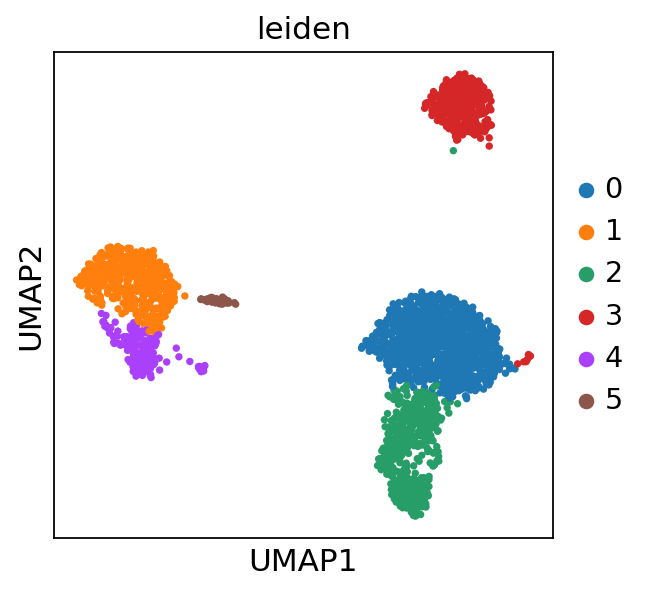

In [58]:
# Example #1: Peripheral Blood Mononuclear Cells (PBMCs) – 3,000 cells

# Load small demo dataset
adata = sc.datasets.pbmc3k()

# Basic preprocessing
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=2000, subset=True)
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, svd_solver='arpack')

# Basic Neighbors + Leiden clustering
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=20)
sc.tl.leiden(adata, resolution=0.5)

# UMAP plot
sc.tl.umap(adata)
sc.pl.umap(adata, color=['leiden'])


In [11]:
# Importing data and storing it in the folder 'data'
!mkdir -p data
!wget -O data/GSE138852_counts.csv.gz "https://ftp.ncbi.nlm.nih.gov/geo/series/GSE138nnn/GSE138852/suppl/GSE138852_counts.csv.gz"
!ls -lh data/

--2025-09-19 04:52:28--  https://ftp.ncbi.nlm.nih.gov/geo/series/GSE138nnn/GSE138852/suppl/GSE138852_counts.csv.gz
Resolving ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)... 130.14.250.13, 130.14.250.31, 130.14.250.7, ...
Connecting to ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)|130.14.250.13|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 12466052 (12M) [application/x-gzip]
Saving to: ‘data/GSE138852_counts.csv.gz’

data/GSE138852_coun 100%[===================>]  11.89M  26.0MB/s    in 0.5s    

2025-09-19 04:52:29 (26.0 MB/s) - ‘data/GSE138852_counts.csv.gz’ saved [12466052/12466052]

total 18M
-rw-r--r-- 1 root root  12M Oct 15  2019 GSE138852_counts.csv.gz
-rw-r--r-- 1 root root 5.6M Sep 19 04:43 pbmc3k_raw.h5ad


In [81]:
# Example #2: Alzheimer's Samples
import scanpy as sc
import pandas as pd
import numpy as np
from scipy import sparse
import os

# Checking to see if data exists in the os path
fn = "data/GSE138852_counts.csv.gz"
if not os.path.exists(fn):
    raise FileNotFoundError(f"{fn} not found — run the wget cell first")

# Reading the csv file and printing array information
print("Reading counts CSV...")
counts = pd.read_csv(fn, index_col=0, compression='gzip')
print("Counts loaded. shape (genes, cells) =", counts.shape)

# Ensures matrix is cells x genes
if counts.shape[0] > counts.shape[1]:
    # genes x cells -> transpose
    X = sparse.csr_matrix(counts.values.T)
    var_names = counts.index.astype(str).tolist()
    obs_names = counts.columns.astype(str).tolist()
else:
    X = sparse.csr_matrix(counts.values)
    var_names = counts.columns.astype(str).tolist()
    obs_names = counts.index.astype(str).tolist()

# Creating an AnnData object and tagging cells with label name
# counts: genes x cells
X = sparse.csr_matrix(counts.values.T)  # transpose → cells x genes
var_names = counts.index.astype(str).tolist()   # genes
obs_names = counts.columns.astype(str).tolist() # cells

# Create AnnData object
adata = sc.AnnData(X, obs=pd.DataFrame(index=obs_names), var=pd.DataFrame(index=var_names))
adata.obs['sample'] = 'GSE138852'
print("AnnData created:", adata)

# SUBSAMPLE for this demo
n_sub = min(2000, adata.n_obs) # choosing 2000 cells or fewer if less available
np.random.seed(1)
subset_idx = np.random.choice(adata.n_obs, n_sub, replace=False)
adata = adata[subset_idx].copy()
print(f"Subsampled to {adata.n_obs} cells for quick demo")

# Preprocessing
sc.pp.filter_genes(adata, min_cells=3)     # drop very rare genes
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=2000, subset=False)
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, svd_solver='arpack')
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=20)
sc.tl.leiden(adata, resolution=0.5)

Reading counts CSV...
Counts loaded. shape (genes, cells) = (10850, 13214)
AnnData created: AnnData object with n_obs × n_vars = 13214 × 10850
    obs: 'sample'
Subsampled to 2000 cells for quick demo
filtered out 10 genes that are detected in less than 3 cells
normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
computing PCA
    with n_comps=50


/usr/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


    finished (0:00:01)
computing neighbors
    using 'X_pca' with n_pcs = 20
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)
running Leiden clustering
    finished: found 10 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:00)


computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:04)
Top 4 most highly expressed genes: ['MGAT3', 'RP11-352M15.2', 'TMOD1', 'C1orf21']


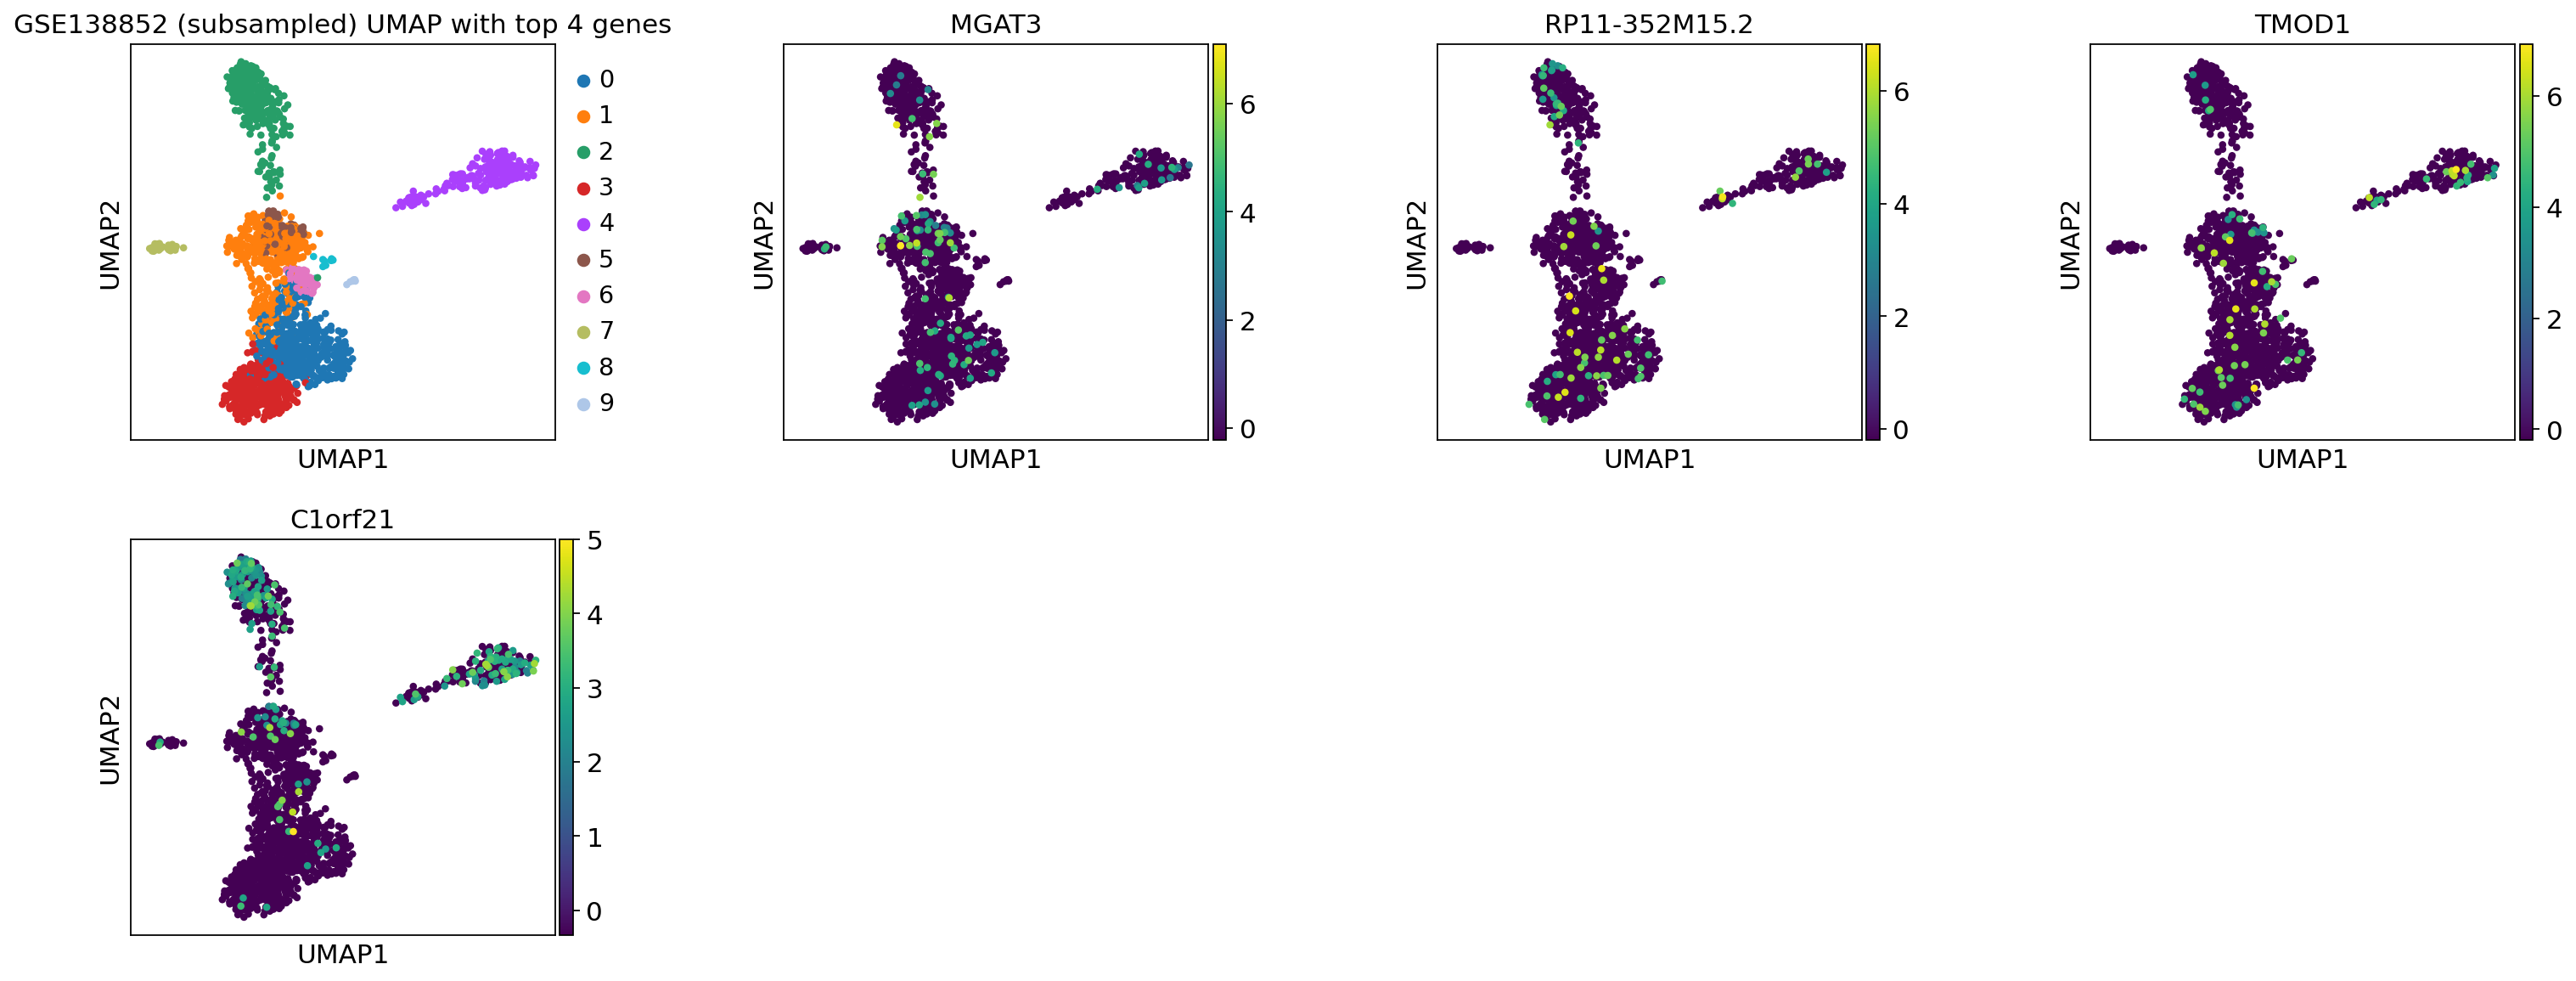

In [82]:
# Data Visualization
sc.tl.umap(adata, n_components=3)

# Getting the most common genes from the subsample
gene_totals = np.array(adata.X.sum(axis=0)).flatten()
top_genes = pd.DataFrame({'gene': adata.var_names, 'total_counts': gene_totals}) \
            .sort_values('total_counts', ascending=False).head(4)['gene'].tolist()

print("Top 4 most highly expressed genes:", top_genes)

# Plot all UMAPs
sc.pl.umap(adata, color=['leiden'] + top_genes, wspace=0.4,
           title='GSE138852 (subsampled) UMAP with top 4 genes')

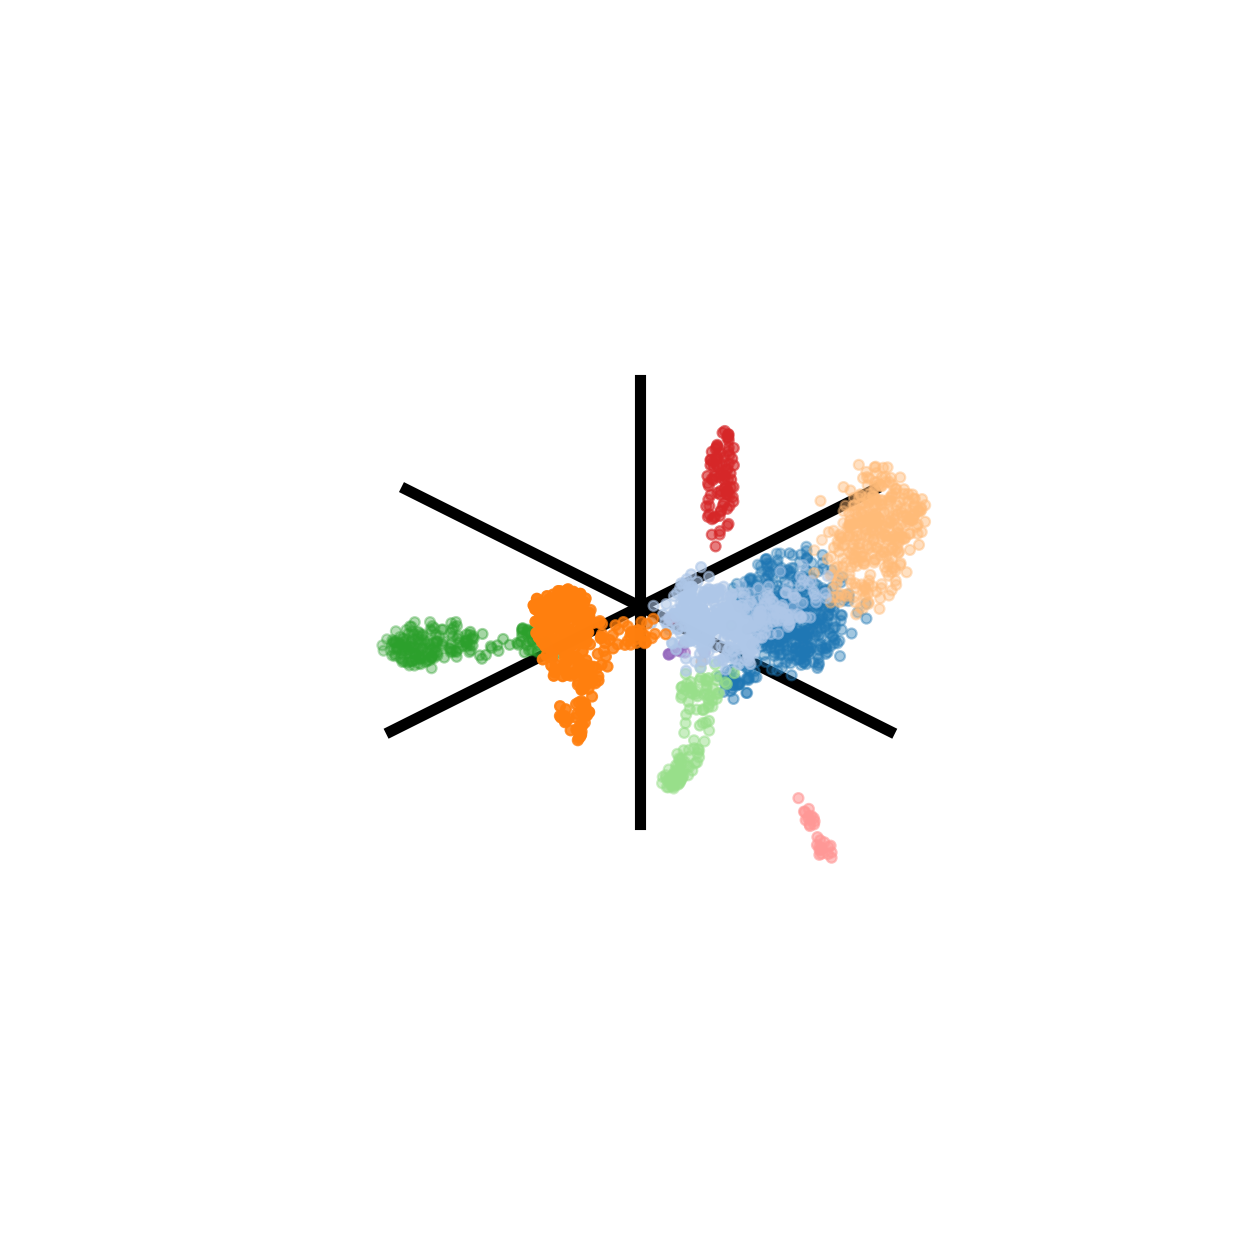

In [84]:
# More advanced plotting using UMAP and Matplotlib
import matplotlib.pyplot as plt
umap = adata.obsm['X_umap']
umap
fig = plt.figure(figsize = (10,10))
ax = fig.add_subplot(projection = '3d')

# Applying color to clusters
color = dict(zip(range(0, 15), plt.cm.tab20(range(0,15))))
ax.scatter(umap[:,0],umap[:,1],umap[:,2], c = adata.obs.leiden.astype('int').map(color))

x_center = (umap[:,0].max() + umap[:,0].min())/2
y_center = (umap[:,1].max() + umap[:,1].min())/2
z_center = (umap[:,2].max() + umap[:,2].min())/2

# Create and set axis
ax.plot([x_center,x_center], [y_center,y_center], [umap[:,2].min() - 2, umap[:,2].max() + 2], c = 'k', lw = 5)
ax.plot([x_center,x_center], [umap[:,1].min() - 2, umap[:,1].max() + 2], [z_center,z_center], c = 'k', lw = 5)
ax.plot([umap[:,0].min() - 2, umap[:,0].max() + 2], [y_center,y_center], [z_center,z_center], c = 'k', lw = 5)

# Set viewing elevation and angle (Edit)
ax.view_init(elev=30, azim=135)

ax.axis('off')

plt.show()